In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
from scipy.stats import zscore

In [2]:
file_paths = ['0000.parquet','0001.parquet','0002.parquet','0003.parquet','0004.parquet','0005.parquet']
dfs = [pd.read_parquet(file) for file in file_paths if os.path.exists(file)]  # Check if files exist
full_data = pd.concat(dfs, ignore_index=True)  # Merge into a single DataFrame


In [3]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10727607 entries, 0 to 10727606
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   videoid     int64 
 1   contentUrl  object
 2   duration    object
 3   page_dir    object
 4   name        object
dtypes: int64(1), object(4)
memory usage: 409.2+ MB


In [4]:
full_data.describe()

,videoid
count,1.072761e+07
mean,5.798212e+08
std,5.044656e+08
min,1.300000e+01
25%,1.906638e+07
50%,1.010962e+09
75%,1.032311e+09
max,1.067376e+09


In [5]:
full_data.head()

,videoid,contentUrl,duration,page_dir,name
0,21179416,https://ak.picdn.net/shutterstock/videos/21179...,PT00H00M11S,006001_006050,Aerial shot winter forest
1,5629184,https://ak.picdn.net/shutterstock/videos/56291...,PT00H00M29S,071501_071550,Senior couple looking through binoculars on sa...
2,1063125190,https://ak.picdn.net/shutterstock/videos/10631...,PT00H00M07S,133701_133750,A beautiful cookie with oranges lies on a gree...
3,1039695998,https://ak.picdn.net/shutterstock/videos/10396...,PT00H00M08S,011901_011950,Japanese highrise office skyscrapers tokyo square
4,9607838,https://ak.picdn.net/shutterstock/videos/96078...,PT00H00M32S,121551_121600,"Zrenjanin,serbia march 21 2015: fans watching ..."


In [6]:
def convert_duration(duration):
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', duration)
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0
    return hours * 3600 + minutes * 60 + seconds

In [7]:
full_data['duration_sec'] = full_data['duration'].apply(lambda x: convert_duration(x) if pd.notnull(x) else 0)

In [8]:
print("Is videoid unique?", full_data['videoid'].is_unique)
print("Duplicate Video Counts:\n", full_data['videoid'].value_counts().head(10))

Is videoid unique? False
Duplicate Video Counts:
 videoid
1066696999    2
1066697260    2
1066676881    2
1065521032    2
1059155453    2
1059150260    2
1062722287    2
1058060785    2
1027554365    2
1065867481    2
Name: count, dtype: int64


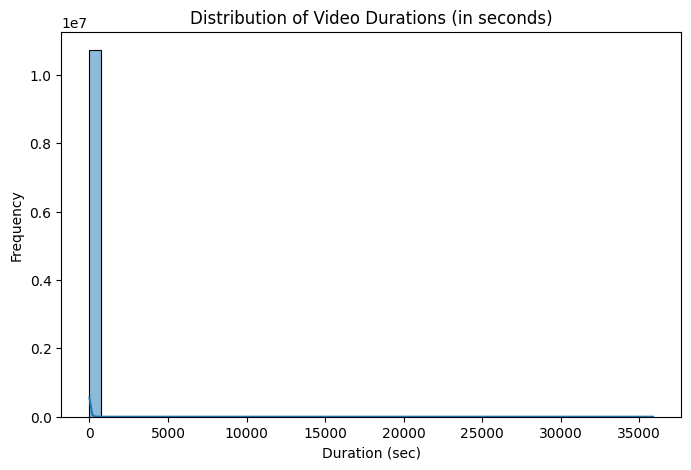

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(full_data['duration_sec'], bins=50, kde=True)
plt.title('Distribution of Video Durations (in seconds)')
plt.xlabel('Duration (sec)')
plt.ylabel('Frequency')
plt.show()

In [10]:
movie_data=full_data

In [11]:
movie_data['duration_sec'] = pd.to_numeric(movie_data['duration_sec'], errors='coerce')

# 1. Identify short videos (0 seconds)
short_videos = movie_data[movie_data['duration_sec'] == 0]

# 2. Identify long videos (> 5 minutes or 300 seconds)
long_videos = movie_data[movie_data['duration_sec'] > 300]

# 3. Print the count of short and long videos
print(f"Number of 0-second videos: {len(short_videos)}")
print(f"Number of long videos (>5 min): {len(long_videos)}")

# 4. Filter out the 0-second and long videos (> 5 min), keeping videos within the 0-5 min range
movie_data = movie_data[(movie_data['duration_sec'] > 0) & (movie_data['duration_sec'] <= 300)]

# Optionally, check the new dataset
print(movie_data.head())

Number of 0-second videos: 270
Number of long videos (>5 min): 271
      videoid                                         contentUrl     duration  \
0    21179416  https://ak.picdn.net/shutterstock/videos/21179...  PT00H00M11S   
1     5629184  https://ak.picdn.net/shutterstock/videos/56291...  PT00H00M29S   
2  1063125190  https://ak.picdn.net/shutterstock/videos/10631...  PT00H00M07S   
3  1039695998  https://ak.picdn.net/shutterstock/videos/10396...  PT00H00M08S   
4     9607838  https://ak.picdn.net/shutterstock/videos/96078...  PT00H00M32S   

        page_dir                                               name  \
0  006001_006050                          Aerial shot winter forest   
1  071501_071550  Senior couple looking through binoculars on sa...   
2  133701_133750  A beautiful cookie with oranges lies on a gree...   
3  011901_011950  Japanese highrise office skyscrapers tokyo square   
4  121551_121600  Zrenjanin,serbia march 21 2015: fans watching ...   

   duration_sec  
0

VIDEO DURATION BY PAGE DIRECTORY

C:\Users\acer\AppData\Local\Temp\ipykernel_12956\2108604174.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=movie_data.head(10), x='page_dir', y='duration_sec', palette='Set2')


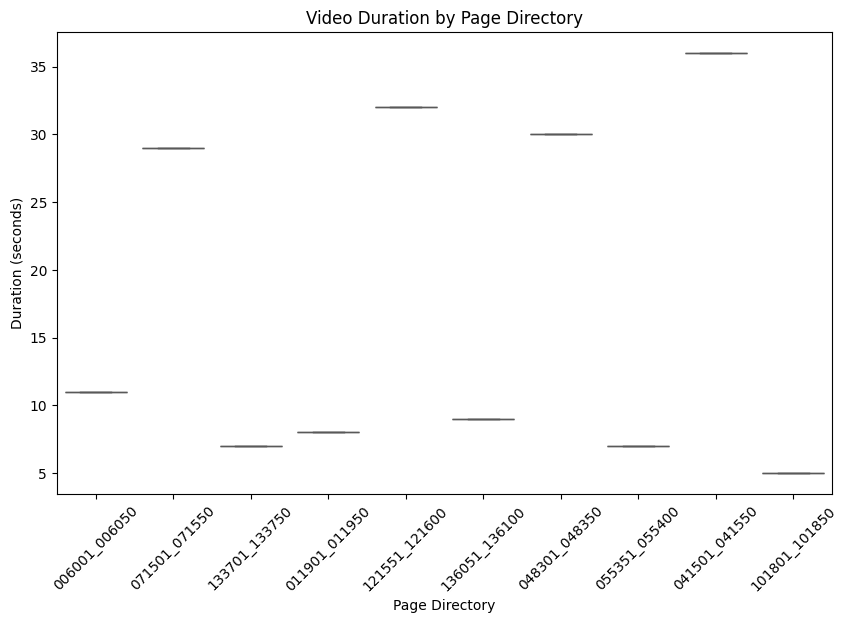

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data=movie_data.head(10), x='page_dir', y='duration_sec', palette='Set2')
plt.title('Video Duration by Page Directory')
plt.xlabel('Page Directory')
plt.ylabel('Duration (seconds)')
plt.xticks(rotation=45)
plt.show()

page_dir
099101_099150    19.140919
040401_040450    18.785806
185601_185650    18.774830
129301_129350    18.773705
094751_094800    18.729557
048501_048550    18.705961
082301_082350    18.704847
094951_095000    18.690372
105551_105600    18.682993
017901_017950    18.654834
Name: duration_sec, dtype: float64


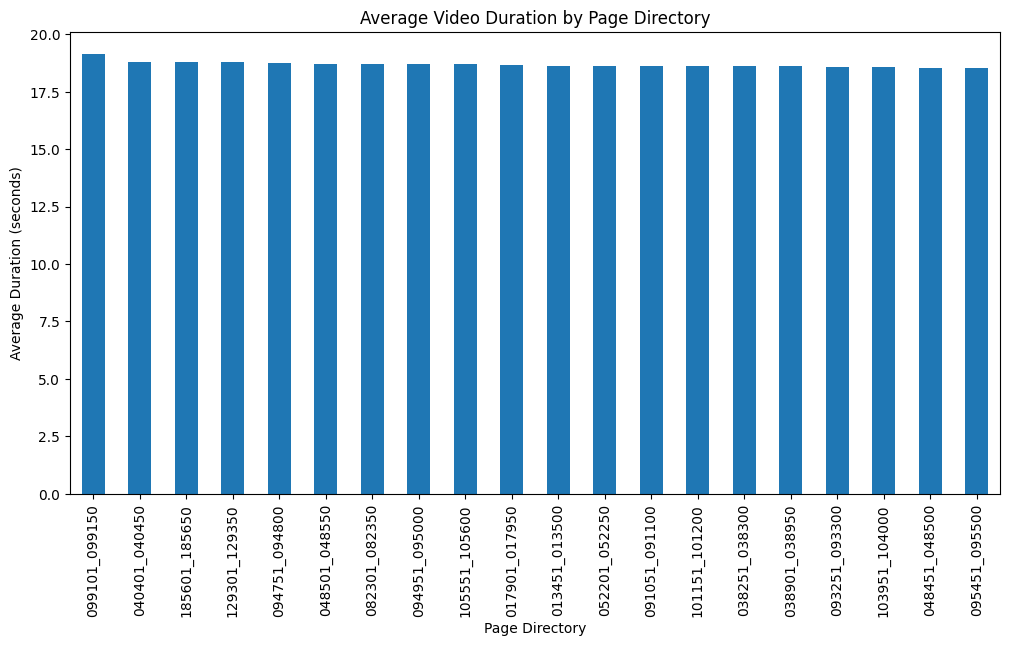

In [13]:
duration_by_category = movie_data.groupby('page_dir')['duration_sec'].mean().sort_values(ascending=False)
print(duration_by_category.head(10))
 
# Bar plot of average duration per category
duration_by_category.head(20).plot(kind='bar', figsize=(12, 6), title='Average Video Duration by Page Directory')
plt.xlabel("Page Directory")
plt.ylabel("Average Duration (seconds)")
plt.show()

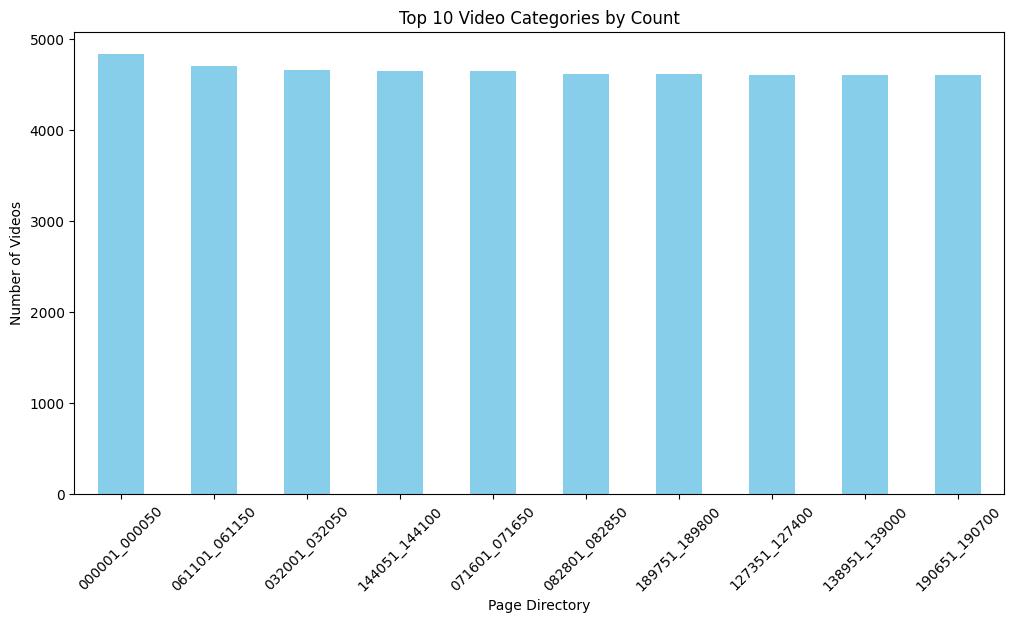

In [20]:
top_categories_count = movie_data['page_dir'].value_counts().head(10)

# Plot the top 10 video categories by count
plt.figure(figsize=(12, 6))
top_categories_count.plot(kind='bar', color='skyblue')
plt.title('Top 10 Video Categories by Count')
plt.xlabel('Page Directory')
plt.ylabel('Number of Videos')
plt.xticks(rotation=45)
plt.show()

VIDEO EXTRACTION

In [14]:
import os
import requests

# Create a directory for saving the videos
save_folder = "downloaded_videos"
if not os.path.exists(save_folder):
    os.makedirs(save_folder)

# Assuming `movie_data` DataFrame contains the 'contentUrl' column with video URLs
video_urls = movie_data['contentUrl'].dropna()  # Drop any NaN URLs

# Limit to first 20 videos
video_urls = video_urls.head(40)

# Function to download videos and save them in the specified folder
def download_video(url, save_folder):
    try:
        video_data = requests.get(url)
        video_name = url.split('/')[-1]  # Extract video name from URL
        save_path = os.path.join(save_folder, video_name)  # Full path for saving the video
        
        # Save the video content to the file
        with open(save_path, 'wb') as file:
            file.write(video_data.content)
        print(f"Video saved: {save_path}")
    except Exception as e:
        print(f"Failed to download {url}: {str(e)}")

# Download the first 20 videos and save to the folder
for url in video_urls:
    download_video(url, save_folder)

print("40 videos have been downloaded and saved.")



Video saved: downloaded_videos\stock-footage-aerial-shot-winter-forest.mp4
Video saved: downloaded_videos\stock-footage-senior-couple-looking-through-binoculars-on-sailboat-together-shot-on-red-epic-for-high-quality-k.mp4
Video saved: downloaded_videos\stock-footage-a-beautiful-cookie-with-oranges-lies-on-a-green-tablecloth.mp4
Video saved: downloaded_videos\stock-footage-japanese-highrise-office-skyscrapers-tokyo-square.mp4
Video saved: downloaded_videos\stock-footage-zrenjanin-serbia-march-fans-watching-live-concert-bokeh-blur-urban-background-x.mp4
Video saved: downloaded_videos\stock-footage-young-beautiful-woman-using-smartphone-in-cafe.mp4
Video saved: downloaded_videos\stock-footage--d-render-of-inky-injections-into-water-with-luma-matte-blue-ink-on-white-background.mp4
Video saved: downloaded_videos\stock-footage-swimming-in-the-pool-slow-motion-fps-handheld-camera-balanced-steady-shot.mp4
Video saved: downloaded_videos\stock-footage-circa-s-usa-woman-posing-for-camera-next-to-

In [16]:
pip install ffmpeg-python opencv-python numpy


Note: you may need to restart the kernel to use updated packages.


In [15]:
import cv2
import os

# Directory containing downloaded videos
video_folder = "downloaded_videos"
frame_output_folder = "extracted_frames"

# Create a directory for extracted frames if it doesn't exist
if not os.path.exists(frame_output_folder):
    os.makedirs(frame_output_folder)

# Function to extract frames from a video
def extract_frames(video_path, output_folder, frame_interval=5):
    """
    Extracts frames from a video at a given interval.

    :param video_path: Path to the video file
    :param output_folder: Folder where frames will be saved
    :param frame_interval: Extract every 'n' frames (default: 30 frames ≈ 1 second at 30fps)
    """
    video_name = os.path.basename(video_path).split('.')[0]  # Extract filename without extension
    save_path = os.path.join(output_folder, video_name)
    
    # Create a folder for each video's frames
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    saved_count = 0
    
    while True:
        success, frame = cap.read()
        if not success:
            break  # Exit loop if no more frames

        # Save every 'frame_interval' frames
        if frame_count % frame_interval == 0:
            frame_filename = os.path.join(save_path, f"frame_{saved_count}.jpg")
            cv2.imwrite(frame_filename, frame)
            saved_count += 1

        frame_count += 1
    
    cap.release()
    print(f"Extracted {saved_count} frames from {video_path} -> {save_path}")

# Process all videos in the folder
for video_file in os.listdir(video_folder):
    video_path = os.path.join(video_folder, video_file)
    if os.path.isfile(video_path) and video_file.endswith((".mp4", ".avi", ".mov", ".mkv")):
        extract_frames(video_path, frame_output_folder)

print("✅ All frames extracted successfully!")


Extracted 181 frames from downloaded_videos\stock-footage--d-render-of-inky-injections-into-water-with-luma-matte-blue-ink-on-white-background.mp4 -> extracted_frames\stock-footage--d-render-of-inky-injections-into-water-with-luma-matte-blue-ink-on-white-background
Extracted 153 frames from downloaded_videos\stock-footage--in-video-the-hand-catch-pencil-and-work-with-blueprint-engineer-project-wide-angle-variable.mp4 -> extracted_frames\stock-footage--in-video-the-hand-catch-pencil-and-work-with-blueprint-engineer-project-wide-angle-variable
Extracted 37 frames from downloaded_videos\stock-footage-a-beautiful-cookie-with-oranges-lies-on-a-green-tablecloth.mp4 -> extracted_frames\stock-footage-a-beautiful-cookie-with-oranges-lies-on-a-green-tablecloth
Extracted 60 frames from downloaded_videos\stock-footage-abstract-background-with-beautiful-color.mp4 -> extracted_frames\stock-footage-abstract-background-with-beautiful-color
Extracted 101 frames from downloaded_videos\stock-footage-abst

STANDARDIZING THE IMAGES

In [16]:
import cv2
import os

# Directories
input_folder = "extracted_frames"  # Folder with extracted frames
output_folder = "standardized_images"  # Folder to save standardized images

# Create output folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Standardization Parameters
TARGET_SIZE = (640, 640)  # Resize all images to this size

# Function to standardize images
def standardize_image(image_path, save_path):
    """
    Standardizes an image by resizing and converting it to grayscale (optional).
    :param image_path: Path to the original image
    :param save_path: Path to save the standardized image
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"⚠️ Warning: Unable to read {image_path}")
        return
    
    # Resize the image
    standardized_image = cv2.resize(image, TARGET_SIZE)
    
    # Save the standardized image
    cv2.imwrite(save_path, standardized_image)

# Iterate through all extracted frames
for video_folder in os.listdir(input_folder):
    video_path = os.path.join(input_folder, video_folder)

    if os.path.isdir(video_path):
        standardized_video_folder = os.path.join(output_folder, video_folder)
        os.makedirs(standardized_video_folder, exist_ok=True)

        for image_file in os.listdir(video_path):
            image_path = os.path.join(video_path, image_file)
            save_path = os.path.join(standardized_video_folder, image_file)

            standardize_image(image_path, save_path)

print("✅ All images have been standardized and saved in 'standardized_images'!")


✅ All images have been standardized and saved in 'standardized_images'!


In [19]:
pip install paddlepaddle paddleocr


Note: you may need to restart the kernel to use updated packages.


OBJECT DETECTION USING YOLOv8 AND FASTER R-CNN

TEXT DETECTION USING PADDLEOCR AND PYTESSERACT

PADDLEOCR

In [17]:
import os
import cv2
import torch
import pytesseract
from ultralytics import YOLO
from torchvision import models, transforms
from paddleocr import PaddleOCR
from PIL import Image
import matplotlib.pyplot as plt

# Define paths
standardized_images_folder = "standardized_images"

# Load Models
# Object Detection
yolo_model = YOLO("yolov8n.pt")  # YOLOv8 model
faster_rcnn = models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
faster_rcnn.eval()

# OCR
ocr_tesseract = pytesseract.pytesseract.tesseract_cmd = r'C:\\Program Files\\Tesseract-OCR\\tesseract.exe'
ocr_paddle = PaddleOCR()

# Image Preprocessing for Faster R-CNN
transform = transforms.Compose([transforms.ToTensor()])

def process_image(image_path):
    image = Image.open(image_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0)
    
    # YOLO Object Detection
    yolo_results = yolo_model(image_path)
    
    # Faster R-CNN Object Detection
    with torch.no_grad():
        outputs = faster_rcnn(img_tensor)
    
    # OCR - Tesseract
    text_tesseract = pytesseract.image_to_string(image)
    
    # OCR - PaddleOCR
    result_paddle = ocr_paddle.ocr(image_path, cls=True)
    text_paddle = '\n'.join([' '.join(line[1][0] for line in res) for res in result_paddle if res])
    
    # Show results
    plt.imshow(image)
    plt.title("Processed Image")
    plt.axis("off")
    plt.show()
    
    return yolo_results, outputs, text_tesseract, text_paddle

# Process all images in the standardized folder
for img_file in os.listdir(standardized_images_folder):
    img_path = os.path.join(standardized_images_folder, img_file)
    if os.path.isfile(img_path):
        yolo_res, rcnn_res, text_tess, text_paddle = process_image(img_path)
        print(f"Processed: {img_file}\n")
        print(f"Tesseract OCR Output:\n{text_tess}")
        print(f"PaddleOCR Output:\n{text_paddle}")
        print("-" * 50)

print("✅ Processing Completed!")


[2025/02/03 21:02:26] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\acer/.paddleocr/whl\\det\\ch\\ch_PP-OCRv4_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\acer/.paddleocr/whl\\rec\\ch\\ch_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6,

YOLO OBJECT DETECTION

In [22]:
from ultralytics import YOLO
from PIL import Image

# Load the model and image
model = YOLO('yolov5s.pt')
image_path = r"standardized_images\stock-footage-a-beautiful-cookie-with-oranges-lies-on-a-green-tablecloth\frame_9.jpg"
img = Image.open(image_path)

# Make predictions
results = model(img)

# The results is a list, so access the first result
result = results[0]

# Display results
result.show()  # Show the image with bounding boxes

# Optionally, save the result
result.save('output_image.jpg')

# Access detection boxes from the result
boxes = result.boxes

# If there are detections, print their details
if len(boxes) > 0:
    for box in boxes:
        # Get bounding box coordinates and confidence
        x1, y1, x2, y2 = box.xyxy[0]  # Get the coordinates of the bounding box
        conf = box.conf[0]  # Get the confidence score
        class_id = box.cls[0]  # Get the class ID of the detected object

        print(f"Class ID: {class_id}, Confidence: {conf:.2f}, Box: ({x1}, {y1}, {x2}, {y2})")
else:
    print("No objects detected.")


PRO TIP  Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


0: 640x640 4 oranges, 5 donuts, 134.0ms
Speed: 16.3ms preprocess, 134.0ms inference, 14.5ms postprocess per image at shape (1, 3, 640, 640)
Class ID: 49.0, Confidence: 0.87, Box: (439.1483459472656, 0.52618408203125, 639.7733154296875, 204.00408935546875)
Class ID: 54.0, Confidence: 0.84, Box: (0.0784149169921875, 235.21502685546875, 137.96066284179688, 557.9559936523438)
Class ID: 54.0, Confidence: 0.70, Box: (0.205596923828125, 1.0721435546875, 178.5267333984375, 260.39324951171875)
Class ID: 54.0, Confidence: 0.66, Box: (21.922515869140625, 349.45001220703125, 258.1932067871094, 638.7837524414062)
Class ID: 54.0, Confidence: 0.64, Box: (142.27191162109375, 466.2105712890625, 475.6912841796875, 639.6123046875)
Class ID: 49.0, Confi

FASTER RCNN OBJECT RECOGNITION

In [8]:
import torch
from torchvision import models, transforms
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Load Faster R-CNN model pre-trained on COCO
faster_rcnn = models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
faster_rcnn.eval()  # Set to evaluation mode

# Define image path
image_path = r"standardized_images\stock-footage-husband-and-wife-admire-the-view-from-their-terrace-balcony-of-new-house-apartment-and-the\frame_28.jpg"
image = Image.open(image_path)

# Preprocess the image (convert to tensor)
transform = transforms.Compose([transforms.ToTensor()])
img_tensor = transform(image).unsqueeze(0)

# Make predictions with Faster R-CNN
with torch.no_grad():
    predictions = faster_rcnn(img_tensor)

# Extract the results
boxes = predictions[0]['boxes']  # Bounding box coordinates
labels = predictions[0]['labels']  # Class labels
scores = predictions[0]['scores']  # Confidence scores

# Display results (image with bounding boxes)
image_copy = image.copy()  # Create a copy of the image to draw on
draw = ImageDraw.Draw(image_copy)

# Set threshold for confidence score (e.g., show detections with score > 0.5)
threshold = 0.5
for box, label, score in zip(boxes, labels, scores):
    if score > threshold:
        # Draw the bounding box
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)

        # Optionally, label the box with class ID and confidence
        draw.text((x1, y1), f"ID: {label}, Conf: {score:.2f}", fill="red")

# Show the result
plt.imshow(image_copy)
plt.title("Faster R-CNN Object Detection")
plt.axis("off")
plt.show()

# Optionally, save the result
image_copy.save('output_faster_rcnn.jpg')

# Print detection details
if len(boxes) > 0:
    for box, label, score in zip(boxes, labels, scores):
        if score > threshold:
            print(f"Class ID: {label.item()}, Confidence: {score:.2f}, Box: ({box[0]}, {box[1]}, {box[2]}, {box[3]})")
else:
    print("No objects detected.")


OSError: [WinError 127] The specified procedure could not be found. Error loading "C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\lib\shm.dll" or one of its dependencies.

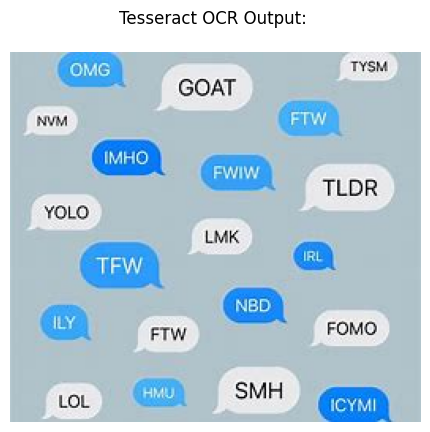

Tesseract OCR Output:



In [3]:
import pytesseract
from PIL import Image
import matplotlib.pyplot as plt

# Define the path to the image
image_path = r"C:\Users\acer\Downloads\OIP (1).jpeg"

# Set the Tesseract executable path (if necessary)
pytesseract.pytesseract.tesseract_cmd = r'C:\\Program Files\\Tesseract-OCR\\tesseract.exe'

# Load the image using PIL
img = Image.open(image_path)

# Run OCR using Pytesseract
text_tesseract = pytesseract.image_to_string(img)

# Display the image with the recognized text using matplotlib
plt.imshow(img)
plt.title(f"Tesseract OCR Output: \n{text_tesseract}")
plt.axis("off")  # Hide axes for better visual appearance
plt.show()

# Print the extracted text
print(f"Tesseract OCR Output:\n{text_tesseract}")


[2025/02/06 11:21:05] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\acer/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\acer/.paddleocr/whl\\rec\\en\\en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6,

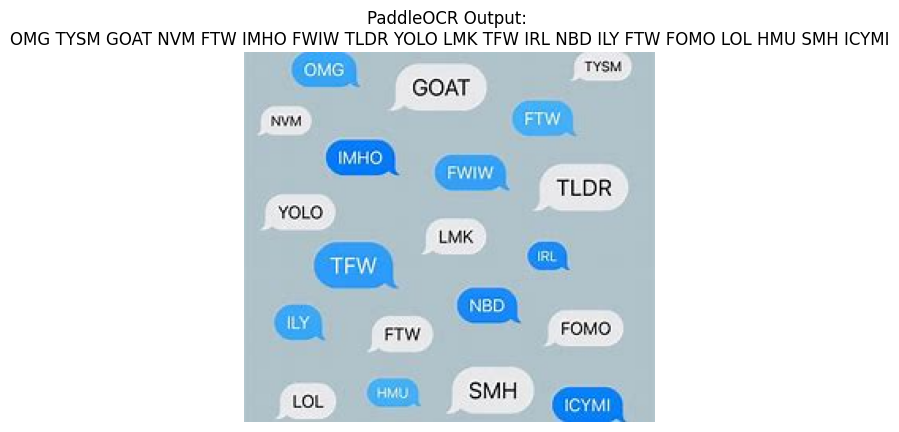

PaddleOCR Output:
OMG TYSM GOAT NVM FTW IMHO FWIW TLDR YOLO LMK TFW IRL NBD ILY FTW FOMO LOL HMU SMH ICYMI


In [7]:
from paddleocr import PaddleOCR
from PIL import Image
import matplotlib.pyplot as plt

# Define the path to the image
image_path = r"C:\Users\acer\Downloads\OIP (1).jpeg"
# Initialize PaddleOCR
ocr_paddle = PaddleOCR(use_angle_cls=True, lang='en')  # Using English language and angle classification

# Run OCR using PaddleOCR
result_paddle = ocr_paddle.ocr(image_path, cls=True)

# Extract text from the result
text_paddle = '\n'.join([' '.join(line[1][0] for line in res) for res in result_paddle if res])

# Display the image with the recognized text using matplotlib
img = Image.open(image_path)
plt.imshow(img)
plt.title(f"PaddleOCR Output: \n{text_paddle}")
plt.axis("off")  # Hide axes for better visual appearance
plt.show()

# Print the extracted text
print(f"PaddleOCR Output:\n{text_paddle}")
